<div align="center">
    <h1>Logistics Network Delay Intelligence: A Graph-Theoretic Approach to ETA Optimization</h1>
    <h3>End-to-End Delay Prediction, Structural Bottleneck Audit, and Route Optimization</h3>
    <p><b>Author:</b> Sumit Jain &nbsp;|&nbsp; IIT Kanpur</p>
</div>

<br>

---


---

##  Phase 1: Data Engineering & The "Cumulative Trap"

###  Objective
The raw Delhivery dataset contains approximately 144,000 individual scan-event rows, each capturing a single checkpoint in a shipment's journey. Before building a meaningful network graph or an ETA predictor, this granular log must be collapsed into **one consolidated row per trip-segment** — a single uninterrupted movement between two distinct facilities.

###  The "Cumulative Trap" & Aggregation Strategy
Rolling up logistics scan data demands careful mathematical thinking. Consider a truck covering 50 km and then an additional 50 km: the distance column in each snapshot is *cumulative*, so blindly summing it yields 150 km (50 + 100) — a phantom 50 km that was never driven. To sidestep this, we enforce strict aggregation discipline over a composite grouping key (`trip_uuid` + `source_center` + `destination_center`):

* **Trip-Level Constants** (e.g., *Route Type, Creation Time*): Captured via `first()` — these values do not change mid-segment.
* **Cumulative Running Totals** (e.g., *OSRM Time, Distance*): Extracted via `max()` — grabbing the final recorded value safely bypasses the double-counting problem.
* **True Per-Scan Measurements** (e.g., *Segment Actual Time*): Aggregated with `sum()` — these are genuine incremental values that are safe to add directly.

###  Re-evaluating Lateness: Driving vs. Dwell
Derived metrics such as delay ratios cannot be averaged across raw snapshot rows; the roll-up distorts them. We therefore recompute them from scratch after consolidation:
1. **Lateness Metrics Recomputed:** Both the **Slowdown Ratio** (a multiplier: *how many times slower than predicted?*) and **Excess Minutes** (the raw gap: *absolute minutes beyond the OSRM estimate*) are derived fresh from the aggregated totals.
2. **Dwell Time Isolation:** A pivotal operational distinction. Subtracting the truck's *net driving time* from the *total elapsed wall-clock time* (first scan to last scan) reveals the pure **Facility Wait Time** — the portion of delay attributable to processing, loading, or queuing inside a hub, entirely separate from road congestion.


In [1]:
import pandas as pd

df = pd.read_csv("delivery_data.csv")
for c in ["trip_creation_time", "od_start_time", "od_end_time", "cutoff_timestamp"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

agg_keys = ["trip_uuid", "source_center", "destination_center", "od_start_time"]

# Cumulative trap fix: actual_time, osrm_time, and osrm_distance are running totals
# in the raw scan log -- max() grabs the final (true) leg value instead of
# summing inflated intermediate checkpoints and producing a phantom distance.
trip_segments = df.groupby(agg_keys, as_index=False).agg(
    data               = ("data", "first"),
    route_type         = ("route_type", "first"),
    trip_creation_time = ("trip_creation_time", "first"),
    source_name        = ("source_name", "first"),
    destination_name   = ("destination_name", "first"),
    od_end_time        = ("od_end_time", "first"),
    start_scan_to_end  = ("start_scan_to_end_scan", "first"),
    actual_time        = ("actual_time", "max"),         # cumulative -- take the final value
    osrm_time          = ("osrm_time", "max"),           # cumulative -- take the final value
    osrm_distance      = ("osrm_distance", "max"),       # cumulative -- take the final value
    actual_distance    = ("actual_distance_to_destination", "max"),
    segment_time_total = ("segment_actual_time", "sum"), # incremental values -- safe to sum
    n_segments         = ("segment_actual_time", "size"),
)

# Recompute both lateness metrics post-rollup; averaging them over raw rows distorts the ratio
trip_segments["slowdown_ratio"]  = trip_segments["actual_time"] / trip_segments["osrm_time"]
trip_segments["excess_minutes"] = trip_segments["actual_time"] - trip_segments["osrm_time"]

# dwell time isolation: wall-clock elapsed minus net driving time = pure facility wait
trip_segments["facility_wait_time"] = trip_segments["start_scan_to_end"] - trip_segments["actual_time"]
trip_segments["facility_wait_time"] = trip_segments["facility_wait_time"].clip(lower=0)

# Time + geography features
trip_segments["hour"]      = trip_segments["od_start_time"].dt.hour
trip_segments["dayofweek"] = trip_segments["od_start_time"].dt.dayofweek
trip_segments["state"]     = trip_segments["source_name"].str.extract(r"\(([^)]+)\)$")

trip_segments = trip_segments[(trip_segments["osrm_time"] > 0) & (trip_segments["actual_time"] > 0)].copy()
trip_segments.to_csv("trip_legs_processed.csv", index=False)

In [2]:
trip_segments.head()

,trip_uuid,source_center,destination_center,od_start_time,data,route_type,trip_creation_time,source_name,destination_name,od_end_time,...,osrm_distance,actual_distance,segment_time_total,n_segments,slowdown_ratio,excess_minutes,facility_wait_time,hour,dayofweek,state
0,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-13 13:40:23.123744,...,446.5496,383.759164,728.0,18,2.097421,383.0,528.0,16,2,Uttar Pradesh
1,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 16:39:46.858469,...,544.8027,440.973689,820.0,21,2.106599,436.0,169.0,0,2,Madhya Pradesh
2,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 03:01:59.598855,...,28.1994,24.644021,46.0,3,1.807692,21.0,11.0,2,2,Karnataka
3,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 02:03:09.655591,...,56.9116,48.542890,95.0,6,2.285714,54.0,26.0,0,2,Karnataka
4,trip-153671043369099517,IND000000ACB,IND160002AAC,2018-09-14 03:40:17.106733,training,FTL,2018-09-12 00:00:33.691250,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),2018-09-14 17:34:55.442454,...,281.2109,242.309306,608.0,12,2.882075,399.0,223.0,3,4,Haryana


## Phase 2: Exploratory Data Analysis (EDA)

### Objective
With trip-segment data now properly consolidated, this phase quantifies the core business problem with statistical rigor. We test whether OSRM predictions systematically underestimate real-world transit times and map exactly where and why those failures concentrate across the logistics network.

### Analysis Strategy
Rather than inspecting raw aggregated time, we stratify three derived delay signals — **Slowdown Ratio**, **Excess Minutes**, and **Facility Wait Time** — across operational dimensions:

* **OSRM Reality Check:** Measure the fraction of trips where actual time exceeds OSRM, and isolate routes suffering chronic delay (slowdown ratio > 1.2×).
* **Distribution Profiling:** Examine the shape of both delay signals to distinguish systemic network congestion from isolated outliers.
* **Operational Stratification:**
  * **Route Type:** Compare FTL vs. Carting delay profiles on shared infrastructure.
  * **Hour of Day:** Track median slowdown ratio across all 24 dispatch hours to identify peak congestion windows.
  * **Distance Bands:** Segment trips by OSRM distance to determine whether short-haul or long-haul legs suffer greater relative delay.
* **Geographic Bottleneck Preview:** Aggregate delay and dwell signals at State, Facility, and Corridor granularity — establishing a ranked list of worst-performing nodes before invoking graph-theoretic methods.
* **Temporal Heatmap:** Cross-tabulate median slowdown ratio by hour of day × day of week to surface intra-week congestion rhythms invisible in single-axis summaries.

actual > OSRM            : 98.2% of legs
actual > OSRM by >20%    : 94.7% of legs
median slowdown ratio    : 2.00x
median minutes lost      : 42 min
median dwell at hub      : 49 min


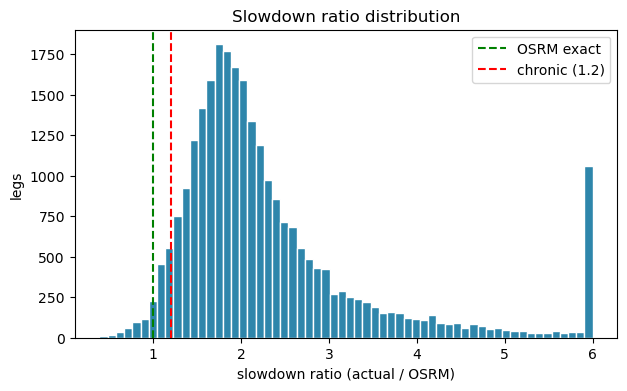

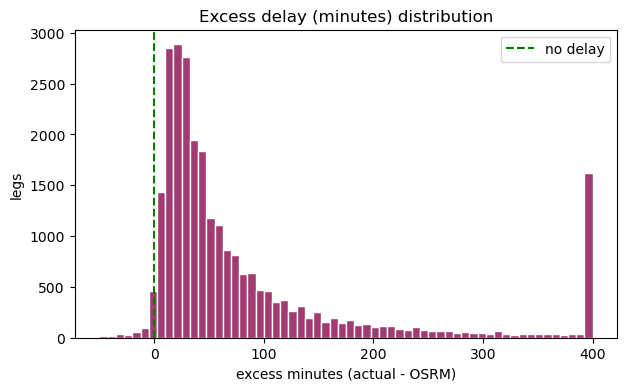


By route type (median):
            slowdown_ratio  excess_minutes  facility_wait_time
route_type                                                    
Carting           2.153846            33.0                50.0
FTL               1.925000            58.0                47.0


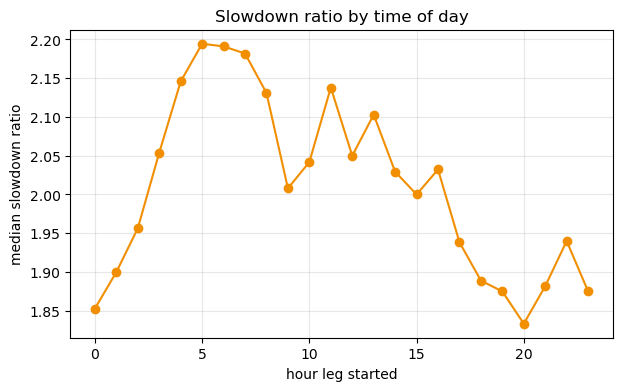


Median slowdown ratio by distance band (km):
dist_bin
0-50       2.071429
50-150     1.950617
150-300    1.961777
300-600    1.975904
600+       1.937105
Name: slowdown_ratio, dtype: float64

Worst hubs by median facility wait time (>=50 legs):
                                      median_dwell  legs
source_name                                             
Hubli_Adargchi_IP (Karnataka)                393.0    78
Aluva_Peedika_H (Kerala)                     352.0    86
Aurangabad_Central_H_1 (Maharashtra)         257.5    58
Rampur_RoshnBgh_I (Uttar Pradesh)            218.0    67
Surat_HUB (Gujarat)                          179.0    93
Ranchi_Hub (Jharkhand)                       176.5    80
Jaipur_Hub (Rajasthan)                       173.0    96
Coimbatore_Karayam_H (Tamil Nadu)            173.0    64
Sonipat_Kundli_H (Haryana)                   169.0   245
Guwahati_Hub (Assam)                         168.0    90


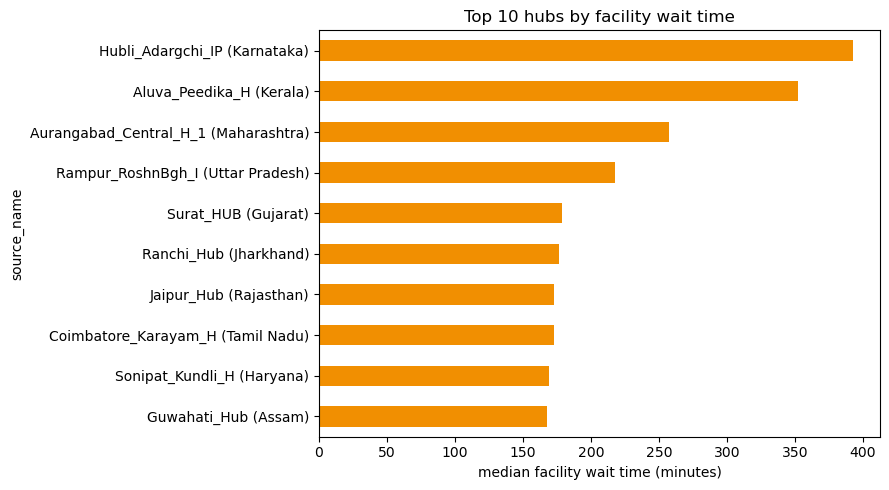


Worst states (>=100 legs):
                  median_factor  median_mins  legs
state                                             
West Bengal            2.577350         56.0  1368
Assam                  2.467376         62.5   484
Bihar                  2.384615         52.0  1060
Maharashtra            2.343653         44.0  3565
Jharkhand              2.310345        108.0   301
Himachal Pradesh       2.226766         62.0   223
Uttar Pradesh          2.098711         45.0  1832
Madhya Pradesh         2.079570         71.5   742
Orissa                 2.078820         83.5   248
Uttarakhand            2.000000         53.0   369

Worst busy corridors (>=30 legs):
                              median_factor  median_mins  legs
corridor                                                      
IND712310AAE -> IND712124AAA       3.730994         50.5    30
IND712311AAA -> IND700088AAA       3.586207         75.0    30
IND500010AAB -> IND501359AAE       3.378378         88.0    39
IND000000A

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

trip_segments = pd.read_csv("trip_legs_processed.csv")

# 1. baseline analysis
print(f"actual > OSRM            : {(trip_segments.slowdown_ratio > 1).mean()*100:.1f}% of legs")
print(f"actual > OSRM by >20%    : {(trip_segments.slowdown_ratio > 1.2).mean()*100:.1f}% of legs")
print(f"median slowdown ratio    : {trip_segments.slowdown_ratio.median():.2f}x")
print(f"median minutes lost      : {trip_segments.excess_minutes.median():.0f} min")
print(f"median dwell at hub      : {trip_segments.facility_wait_time.median():.0f} min")

# 2. slowdown ratio distribution
figure, axis = plt.subplots(figsize=(7, 4))
axis.hist(trip_segments.slowdown_ratio.clip(upper=6), bins=60, color="#2E86AB", edgecolor="white")
axis.axvline(1.0, color="green", ls="--", label="OSRM exact")
axis.axvline(1.2, color="red",   ls="--", label="chronic (1.2)")
axis.set(xlabel="slowdown ratio (actual / OSRM)", ylabel="legs", title="Slowdown ratio distribution")
axis.legend(); plt.show()

# 3. excess minutes distribution
figure, axis = plt.subplots(figsize=(7, 4))
axis.hist(trip_segments.excess_minutes.clip(lower=-50, upper=400), bins=60, color="#A23B72", edgecolor="white")
axis.axvline(0, color="green", ls="--", label="no delay")
axis.set(xlabel="excess minutes (actual - OSRM)", ylabel="legs", title="Excess delay (minutes) distribution")
axis.legend(); plt.show()

# 4. route type breakdown
print("\nBy route type (median):")
print(trip_segments.groupby("route_type")[["slowdown_ratio", "excess_minutes", "facility_wait_time"]].median())

# 5. hour of day
by_hour = trip_segments.groupby("hour")["slowdown_ratio"].median()
figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(by_hour.index, by_hour.values, marker="o", color="#F18F01")
axis.set(xlabel="hour leg started", ylabel="median slowdown ratio", title="Slowdown ratio by time of day")
axis.grid(alpha=0.3); plt.show()

# 6. distance bands
trip_segments["dist_bin"] = pd.cut(trip_segments.osrm_distance, [0,50,150,300,600,1e5],
                          labels=["0-50","50-150","150-300","300-600","600+"])
print("\nMedian slowdown ratio by distance band (km):")
print(trip_segments.groupby("dist_bin", observed=True)["slowdown_ratio"].median())

# 7. worst hubs by facility wait time
hub_dwell = (trip_segments.groupby("source_name")
                 .agg(median_dwell=("facility_wait_time", "median"), legs=("facility_wait_time", "size"))
                 .query("legs >= 50")
                 .sort_values("median_dwell", ascending=False)
                 .head(10))
print("\nWorst hubs by median facility wait time (>=50 legs):")
print(hub_dwell)
figure, axis = plt.subplots(figsize=(9, 5))
hub_dwell["median_dwell"].iloc[::-1].plot(kind="barh", color="#F18F01", ax=axis)
axis.set(xlabel="median facility wait time (minutes)", title="Top 10 hubs by facility wait time")
plt.tight_layout(); plt.show()

# 8. worst states and corridors
print("\nWorst states (>=100 legs):")
print(trip_segments.groupby("state")
          .agg(median_factor=("slowdown_ratio","median"), median_mins=("excess_minutes","median"), legs=("slowdown_ratio","size"))
          .query("legs >= 100").sort_values("median_factor", ascending=False).head(10))

trip_segments["corridor"] = trip_segments.source_center + " -> " + trip_segments.destination_center
print("\nWorst busy corridors (>=30 legs):")
print(trip_segments.groupby("corridor")
          .agg(median_factor=("slowdown_ratio","median"), median_mins=("excess_minutes","median"), legs=("slowdown_ratio","size"))
          .query("legs >= 30").sort_values("median_factor", ascending=False).head(10))

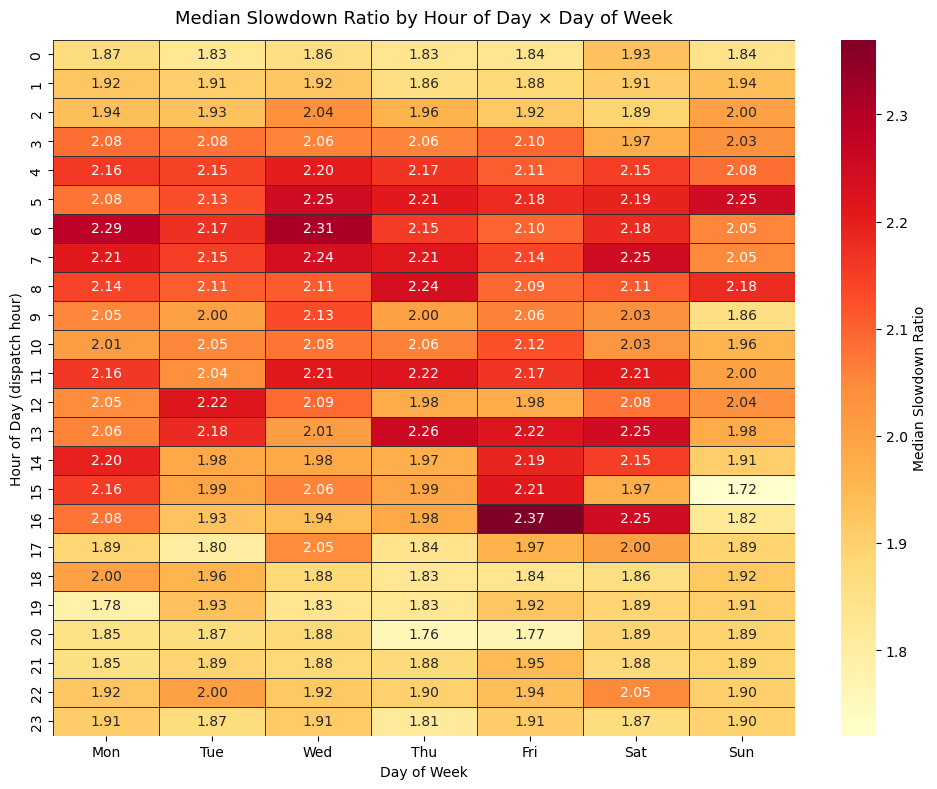

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

trip_segments = pd.read_csv("trip_legs_processed.csv")

# median slowdown_ratio by hour_of_day (rows) × day_of_week (columns)
pivot = trip_segments.pivot_table(
    values="slowdown_ratio",
    index="hour",
    columns="dayofweek",
    aggfunc="median"
)
pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

figure, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#333",
    cbar_kws={"label": "Median Slowdown Ratio"},
    ax=axis
)
axis.set_title("Median Slowdown Ratio by Hour of Day \u00d7 Day of Week", fontsize=13, pad=12)
axis.set_xlabel("Day of Week")
axis.set_ylabel("Hour of Day (dispatch hour)")
plt.tight_layout(); plt.show()

## Phase 3: Network Graph Construction

### Objective
We translate the cleaned trip-segment tabular data into a **Directed Weighted Graph** — a structural map of the logistics network — enabling graph-theoretic analysis unavailable to purely tabular models.

### Graph Schema
* **Nodes (Facilities):** Every unique source and destination center becomes a distinct node, annotated with its human-readable facility name.
* **Edges (Corridors):** Physical lanes connecting two facilities. A *Directed* graph (`DiGraph`) is essential because delay patterns are fundamentally asymmetric — congestion on the Gurgaon → Bangalore corridor operates under entirely different conditions than the reverse lane.
* **Edge Weight:** Each edge is weighted by the **Median Slowdown Ratio** — a normalized delay multiplier capturing how much slower than OSRM a given corridor typically runs.

### Stratification Layers
1. **By Route Type:** Separate median slowdown ratios for FTL and Carting on the same physical corridor, revealing where vehicle type drives delay rather than road conditions.
2. **By Time Window:** Dispatch hours are mapped to four operational windows — **pre-dawn** (00:00–05:59), **peak-am** (06:00–11:59), **midday** (12:00–17:59), **peak-pm** (18:00–23:59) — capturing how network chokepoints shift through the operating day.

In [5]:
import pandas as pd
import networkx as nx

trip_segments = pd.read_csv("trip_legs_processed.csv")

# time-of-day stratification
def get_time_window(h):
    return "pre-dawn" if h < 6 else "peak-am" if h < 12 else "midday" if h < 18 else "peak-pm"
trip_segments["tod"] = trip_segments["hour"].apply(get_time_window)

# aggregate trip segments into route corridors
route_edges = trip_segments.groupby(["source_center", "destination_center"]).agg(
    median_delay_factor   = ("slowdown_ratio",    "median"),   # edge weight
    median_delay_minutes  = ("excess_minutes",    "median"),
    median_hub_processing = ("facility_wait_time","median"),
    median_osrm_distance  = ("osrm_distance",     "median"),
    n_legs                = ("trip_uuid",         "size"),
).reset_index()

# stratify slowdown ratio by route type and time window
for strat in ["route_type", "tod"]:
    s = (trip_segments.groupby(["source_center", "destination_center", strat])["slowdown_ratio"]
             .median().unstack())
    s.columns = [f"median_delay_factor_{c}" for c in s.columns]
    route_edges = route_edges.merge(s, on=["source_center", "destination_center"], how="left")

# build directed weighted graph
logistics_graph = nx.DiGraph()
for _, r in route_edges.iterrows():
    logistics_graph.add_edge(r.source_center, r.destination_center,
               weight   = r.median_delay_factor,
               n_legs   = r.n_legs,
               dwell    = r.median_hub_processing,
               minutes  = r.median_delay_minutes)

# annotate nodes with facility names
names = (pd.concat([trip_segments[["source_center","source_name"]].rename(columns={"source_center":"c","source_name":"n"}),
                    trip_segments[["destination_center","destination_name"]].rename(columns={"destination_center":"c","destination_name":"n"})])
           .dropna().drop_duplicates("c").set_index("c")["n"].to_dict())
nx.set_node_attributes(logistics_graph, names, "name")

route_edges.to_csv("route_corridors.csv", index=False)
print("nodes:", logistics_graph.number_of_nodes(), "edges:", logistics_graph.number_of_edges())

nodes: 1657 edges: 2783


### Network Visualization (PyVis Interactive)

The full logistics graph is rendered as an interactive HTML map to allow exploratory navigation of all 1,600+ facility nodes and 2,700+ corridor edges.

Encoding conventions:
* **Edge Thickness (Traffic Volume):** Proportional to `n_legs` — thicker lanes carry heavier shipment volumes.
* **Hover Tooltip:** Reveals the median slowdown ratio for any corridor on mouse-over.

In [6]:
from pyvis.network import Network
import pandas as pd, networkx as nx

route_edges = pd.read_csv("route_corridors.csv")
logistics_graph = nx.DiGraph()
for _, r in route_edges.iterrows():
    logistics_graph.add_edge(r.source_center, r.destination_center,
               value=float(r.n_legs),
               title=f"delay {r.median_delay_factor:.2f}")
net = Network(height="800px", width="100%", directed=True, notebook=False)
net.from_nx(logistics_graph)
net.write_html("network.html")

## Phase 4: Structural Bottleneck & Corridor Audit

### Objective
With systemic delay established, this phase locates the exact physical nodes and lanes that account for the largest share of total network lateness — providing actionable intelligence for operational intervention.

### Hub-Level Metrics
For every facility in the network, four complementary metrics are computed:

1. **Betweenness Centrality (`centrality_scores`):** Quantifies how frequently a hub sits on the shortest path between any two other nodes. A high score signals a structural chokepoint — its failure would disconnect large network segments with no viable bypass.
2. **In/Out-Degree:** Count of inbound and outbound corridors. High degree implies heavy consolidation load and complex scheduling dependency.
3. **Clustering Coefficient:** Measures interconnectedness among a hub's neighbors. Low clustering identifies "hub-and-spoke" topologies where the central node is an irreplaceable single point of failure.
4. **Network Delay Share (`hub_impact`):** Each facility's contribution to total excess minutes across the network, weighted by both delay severity and shipment volume — isolating the facilities where time bleeds most.

### Chronic Corridor Detection
Lane-level audit flags corridors where median slowdown ratio exceeds 1.2× as **Chronic Corridors**. Sorting by cumulative excess minutes instantly prioritizes lanes for operational intervention — rerouting, mode shift (Carting → FTL), or capacity investment.

In [7]:
import pandas as pd
import networkx as nx

route_edges   = pd.read_csv("route_corridors.csv")
trip_segments = pd.read_csv("trip_legs_processed.csv")

# build graph
logistics_graph = nx.DiGraph()
for _, r in route_edges.iterrows():
    logistics_graph.add_edge(r.source_center, r.destination_center,
               weight=r.median_delay_factor, n_legs=r.n_legs)
core_graph = logistics_graph.subgraph(max(nx.weakly_connected_components(logistics_graph), key=len)).copy()
print(f"full: {logistics_graph.number_of_nodes()} nodes / {logistics_graph.number_of_edges()} edges | "
      f"core (largest CC): {core_graph.number_of_nodes()} nodes")

# compute hub metrics
indeg  = pd.Series(dict(logistics_graph.in_degree()))
outdeg = pd.Series(dict(logistics_graph.out_degree()))
centrality_scores = pd.Series(nx.betweenness_centrality(core_graph, normalized=True))
clust  = pd.Series(nx.clustering(core_graph))

# hub delay contribution
total_network_delay = trip_segments["excess_minutes"].sum()
hub_impact = (trip_segments.groupby("source_center")
              .agg(total_excess_min  = ("excess_minutes",    "sum"),
                   n_legs_dispatched = ("excess_minutes",    "size"),
                   median_dwell      = ("facility_wait_time","median")))
hub_impact["pct_network_delay"] = hub_impact.total_excess_min / total_network_delay * 100

# assemble hub profiles
names = (pd.concat([
            trip_segments[["source_center","source_name"]].rename(columns={"source_center":"c","source_name":"n"}),
            trip_segments[["destination_center","destination_name"]].rename(columns={"destination_center":"c","destination_name":"n"})])
         .dropna().drop_duplicates("c").set_index("c")["n"])
hub_profiles = pd.DataFrame({"in_deg":indeg, "out_deg":outdeg,
                      "betweenness":centrality_scores, "clustering":clust}).join(hub_impact)
hub_profiles["name"] = hub_profiles.index.map(names)
hub_profiles[["betweenness","clustering"]] = hub_profiles[["betweenness","clustering"]].fillna(0)
hub_profiles = hub_profiles.fillna(0)
hub_profiles.to_csv("facility_scores.csv")

# chronic corridor flagging
route_edges["chronic"] = route_edges.median_delay_factor > 1.2
corr_excess = (trip_segments.groupby(["source_center","destination_center"])["excess_minutes"]
                   .sum().rename("total_excess_min").reset_index())
route_edges = route_edges.merge(corr_excess, on=["source_center","destination_center"])
route_edges.to_csv("chronic_corridors.csv", index=False)

print("\nTOP 8 BOTTLENECK HUBS (by % network delay)")
print(hub_profiles.sort_values("pct_network_delay", ascending=False).head(8)
      [["name","pct_network_delay","betweenness","in_deg","out_deg","clustering","median_dwell"]].round(3).to_string())

print(f"\nchronic corridors: {route_edges.chronic.sum()} of {len(route_edges)} ({route_edges.chronic.mean()*100:.0f}%)")
print("\nTOP 8 CHRONIC CORRIDORS (by total excess-minutes)")
print(route_edges[route_edges.chronic].sort_values("total_excess_min", ascending=False).head(8)
      [["source_center","destination_center","median_delay_factor","n_legs","total_excess_min"]].round(1).to_string(index=False))

full: 1657 nodes / 2783 edges | core (largest CC): 1353 nodes

TOP 8 BOTTLENECK HUBS (by % network delay)
                                           name  pct_network_delay  betweenness  in_deg  out_deg  clustering  median_dwell
IND000000ACB      Gurgaon_Bilaspur_HB (Haryana)             14.685        0.330      45       49       0.027         155.0
IND421302AAG  Bhiwandi_Mankoli_HB (Maharashtra)              6.345        0.104      29       29       0.059         142.0
IND562132AAA   Bangalore_Nelmngla_H (Karnataka)              5.461        0.187      36       35       0.055         140.0
IND411033AAA      Pune_Tathawde_H (Maharashtra)              2.584        0.065      23       20       0.053         112.0
IND712311AAA   Kolkata_Dankuni_HB (West Bengal)              2.431        0.136      24       22       0.032         116.5
IND501359AAE   Hyderabad_Shamshbd_H (Telangana)              2.078        0.139      30       27       0.037         160.0
IND781018AAB               Guwaha

### Bottleneck Map: Interactive Risk Visualization (PyVis)

An interactive HTML map isolates the **top 40 highest-risk facilities** — those ranked by betweenness centrality — overlaid with their SLA impact signal.

Visual encoding:
* **Node Size:** Driven by Betweenness Centrality — larger nodes represent structural single points of failure whose removal would fracture the network.
* **Node Color:** Driven by percentage of total network delay — darker red nodes are the primary locations where shipment time is lost.
* **Edge Width:** Proportional to traffic volume (`n_legs`).
* **Edge Color:** Yellow-to-red gradient mapped to the corridor's slowdown ratio severity.

In [8]:
import pandas as pd, networkx as nx
from pyvis.network import Network
import matplotlib.cm as cm, matplotlib.colors as mcolors

route_edges = pd.read_csv("route_corridors.csv")
hub_profiles = pd.read_csv("facility_scores.csv", index_col=0)

TOPN = 40
top = hub_profiles.sort_values("betweenness", ascending=False).head(TOPN).index.tolist()
sub = route_edges[(route_edges.source_center.isin(top)) & (route_edges.destination_center.isin(top))]

def red(x, lo, hi):                                   # value in red/orange hex
    return mcolors.to_hex(cm.YlOrRd(min(max((x-lo)/(hi-lo), 0), 1)))

net = Network(height="800px", width="100%", directed=True,
              bgcolor="#111827", font_color="#e6e6e6", notebook=False)
net.barnes_hut(gravity=-9000, central_gravity=0.25, spring_length=130, spring_strength=0.02)

# for nodes: size = betweenness, colour = share in delay
for n in top:
    row   = hub_profiles.loc[n]
    city  = row["name"].split("_")[0]
    state = row["name"].split("(")[-1].rstrip(")") if "(" in row["name"] else ""
    net.add_node(
        n, label=city,
        size=14 + row.betweenness*160,
        color={"background": red(row.pct_network_delay, 0, 16),
               "border": "#222", "highlight": {"background": "#3B82F6", "border": "#000"}},
        borderWidth=1.5, font={"size": 16, "color": "#ffffff", "strokeWidth": 3, "strokeColor": "#000"},
        title=(f"<b>{row['name']}</b><br>State: {state}<br>━━━━━━━━━━<br>"
               f"Delay share: <b>{row.pct_network_delay:.1f}%</b> of network<br>"
               f"Betweenness: <b>{row.betweenness:.3f}</b><br>"
               f"In / Out corridors: {int(row.in_deg)} / {int(row.out_deg)}<br>"
               f"Clustering: {row.clustering:.3f}<br>"
               f"Median dwell: {row.median_dwell:.0f} min<br>"
               f"Legs dispatched: {int(row.n_legs_dispatched)}"))

# for edges: width = traffic, colour = delay factor
for _, r in sub.iterrows():
    net.add_edge(r.source_center, r.destination_center,
                 width=1 + r.n_legs/12,
                 color=red(r.median_delay_factor, 1, 3),
                 title=(f"{r.median_delay_factor:.2f}x slower than OSRM<br>"
                        f"{int(r.n_legs)} legs &middot; {r.median_delay_minutes:.0f} min median delay"))

net.write_html("bottlenecks_pro.html")

# injecting legend and title overlay
legend = """
<div style="position:fixed;top:14px;left:14px;background:rgba(20,24,31,.94);color:#e6e6e6;
border:1px solid #333;border-radius:10px;padding:14px 16px;font-family:system-ui,sans-serif;
font-size:13px;z-index:999;box-shadow:0 4px 14px rgba(0,0,0,.5);max-width:270px;">
<div style="font-size:15px;font-weight:700;margin-bottom:2px;">Logistics Delay Risk Map</div>
<div style="color:#9aa;font-size:11px;margin-bottom:8px;">Top 40 facilities by structural risk index</div>
<div style="margin:6px 0;"><b>Node size</b> &rarr; betweenness (chokepoint risk)</div>
<div><b>Node colour</b> &rarr; % of total network delay</div>
<div style="height:11px;width:200px;border-radius:3px;margin:5px 0;
background:linear-gradient(to right,#ffffcc,#feb24c,#f03b20,#bd0026);"></div>
<div style="display:flex;justify-content:space-between;font-size:11px;color:#9aa;width:200px;">
<span>0%</span><span>8%</span><span>16%+</span></div>
<div style="margin:8px 0 2px;"><b>Edge width</b> &rarr; traffic (number of legs)</div>
<div><b>Edge colour</b> &rarr; corridor delay factor (red = worse)</div>
<hr style="border-color:#333;margin:9px 0;">
<div style="font-size:11px;color:#9aa;">Hover a hub for full metrics &middot; drag &middot; scroll to zoom</div>
</div>
"""
html = open("bottlenecks_pro.html").read().replace("<body>", "<body>" + legend)
open("bottlenecks_pro.html", "w").write(html)
print("wrote bottlenecks_pro.html")

wrote bottlenecks_pro.html


### Executive Charting: Bottleneck Profiles

Static ranked charts distill the interactive map into presentation-ready findings, isolating worst-offending facilities and lanes for stakeholder reporting.

* **Chart A — SLA Impact Ranking:** Top 10 facilities by their cumulative share of total network delay minutes.
* **Chart B — Structural Risk Ranking:** Top 10 facilities by Betweenness Centrality, highlighting un-bypassable routing chokepoints.
* **Chart C — Chronic Lane Failures:** Top 10 chronic corridors ranked by accumulated excess minutes — direct candidates for mode-shift or capacity investment.
* **Chart D — Risk × Impact Scatter:** Plots structural chokepoint score against SLA delay share. The positive correlation confirms that topological bottlenecks are also the primary delay drivers; top 8 outliers are annotated by city name.

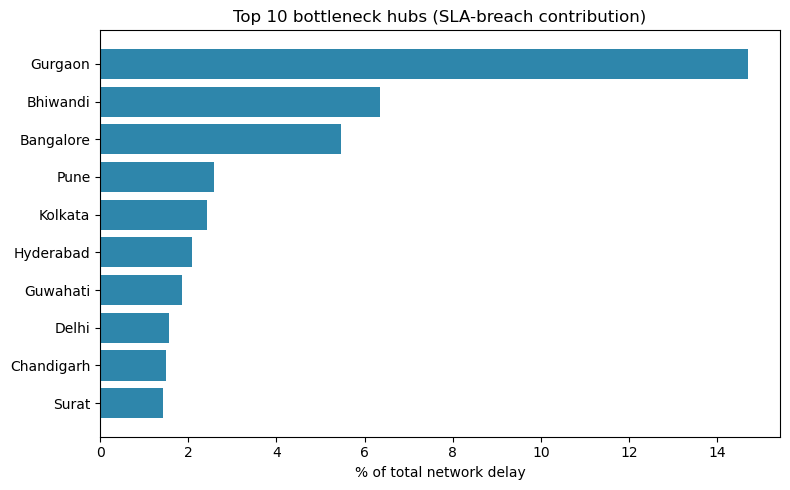

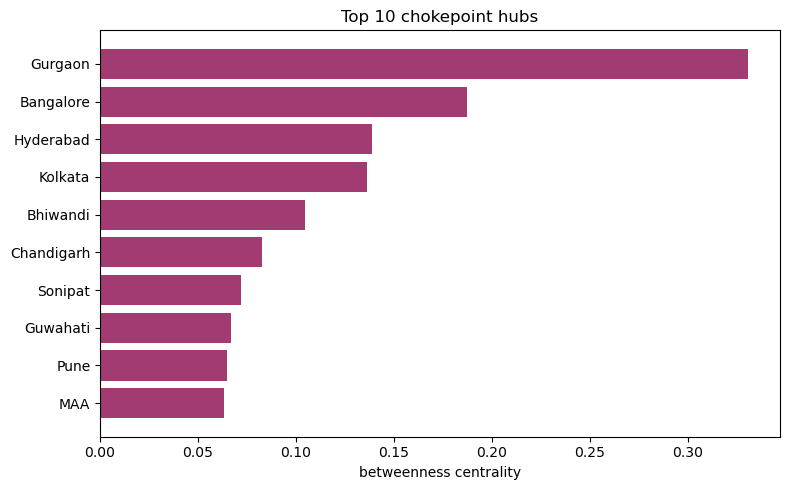

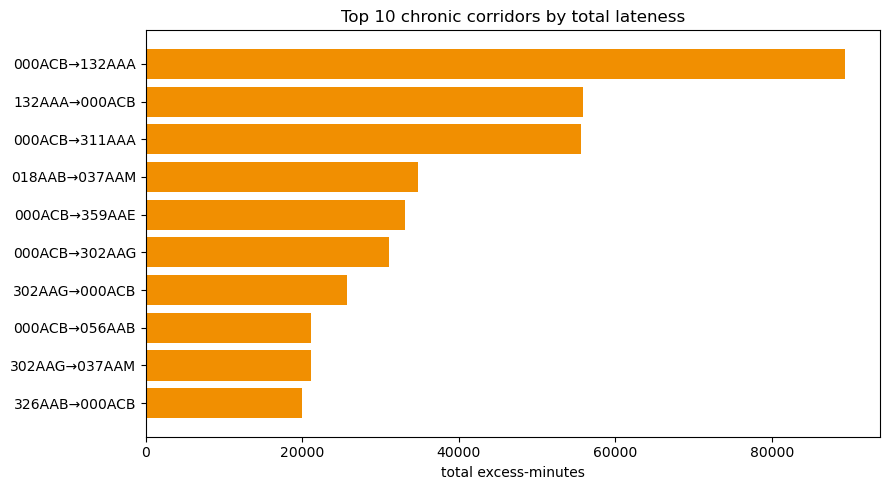

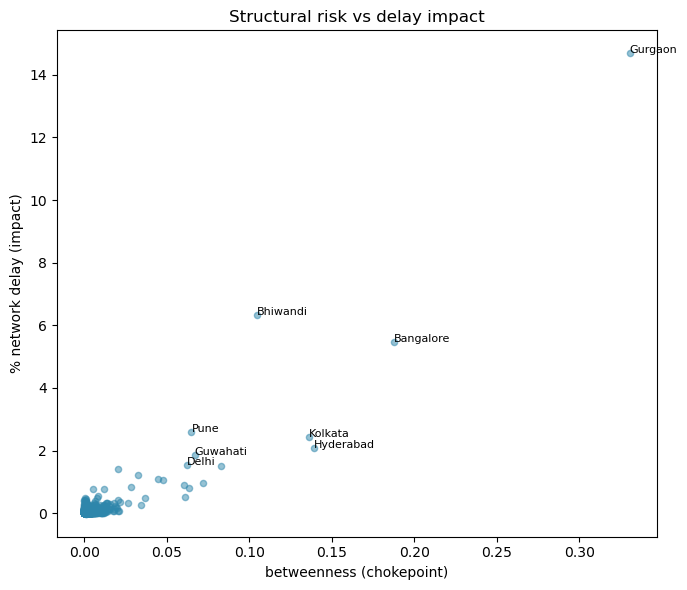

In [9]:
import pandas as pd, matplotlib.pyplot as plt

hub_profiles = pd.read_csv("facility_scores.csv", index_col=0)
route_edges  = pd.read_csv("chronic_corridors.csv")

short = lambda s: s.str.split("_").str[0]

# Chart A — SLA impact
top = hub_profiles.sort_values("pct_network_delay", ascending=False).head(10)
figure, axis = plt.subplots(figsize=(8,5))
axis.barh(short(top["name"])[::-1], top["pct_network_delay"][::-1], color="#2E86AB")
axis.set(xlabel="% of total network delay", title="Top 10 bottleneck hubs (SLA-breach contribution)")
plt.tight_layout(); plt.show()

# Chart B — structural risk
topb = hub_profiles.sort_values("betweenness", ascending=False).head(10)
figure, axis = plt.subplots(figsize=(8,5))
axis.barh(short(topb["name"])[::-1], topb["betweenness"][::-1], color="#A23B72")
axis.set(xlabel="betweenness centrality", title="Top 10 chokepoint hubs")
plt.tight_layout(); plt.show()

# Chart C — chronic corridors
tc = route_edges[route_edges.chronic].sort_values("total_excess_min", ascending=False).head(10)
labels = (tc.source_center.str[-6:] + "→" + tc.destination_center.str[-6:])
figure, axis = plt.subplots(figsize=(9,5))
axis.barh(labels[::-1], tc["total_excess_min"][::-1], color="#F18F01")
axis.set(xlabel="total excess-minutes", title="Top 10 chronic corridors by total lateness")
plt.tight_layout(); plt.show()

# Chart D — structural risk vs delay impact (annotate top 8)
figure, axis = plt.subplots(figsize=(7,6))
axis.scatter(hub_profiles["betweenness"], hub_profiles["pct_network_delay"], s=20, alpha=.5, color="#2E86AB")
for n in hub_profiles.sort_values("pct_network_delay", ascending=False).head(8).index:
    axis.annotate(short(pd.Series([hub_profiles.loc[n,"name"]])).iloc[0],
                (hub_profiles.loc[n,"betweenness"], hub_profiles.loc[n,"pct_network_delay"]), fontsize=8)
axis.set(xlabel="betweenness (chokepoint)", ylabel="% network delay (impact)",
       title="Structural risk vs delay impact")
plt.tight_layout(); plt.show()

## Phase 5: Graph-Enhanced ETA Prediction

### Objective
Standard ETA models treat each shipment in isolation, ignoring the structural context of where a route sits within the broader network. This phase proves that granting a model **spatial awareness** of network topology measurably reduces prediction error and improves SLA compliance.

### Model Architectures
Three escalating levels of network intelligence are evaluated using a high-performance Gradient Boosting algorithm (`HistGradientBoostingRegressor`):

1. **Baseline:** Standard tabular features only — OSRM estimated time, physical distance, route type, and dispatch hour. Completely blind to network topology and cascade effects.
2. **Spatial Model (Node2Vec):** Generates 24-dimensional spatial embeddings per facility via random walks on the graph. The regressor learns *where* a route sits within the network, capturing positional bias in delay patterns.
3. **GNN Model (GraphSAGE / `GraphEncoder`):** A custom deep learning encoder aggregates hub-level congestion features — Betweenness Centrality, In/Out-Degree, Clustering — from neighboring nodes via 80 training epochs with 48 hidden dimensions. The model effectively looks ahead for downstream bottlenecks before a shipment departs.

### Evaluation Metrics
* **Mean Absolute Error (MAE):** Average deviation from actual transit time, in minutes.
* **Within-15% SLA Compliance:** Percentage of predictions landing within a ±15% margin of actual time.
* **Within-20% SLA Compliance:** A secondary, more permissive compliance band for operational planning benchmarking.

In [10]:
import pandas as pd, numpy as np, networkx as nx
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from node2vec import Node2Vec

trip_segments = pd.read_csv("trip_legs_processed.csv")
route_edges   = pd.read_csv("chronic_corridors.csv")
trip_segments["is_ftl"] = (trip_segments.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]

w15 = lambda yt, yp: (np.abs(yp - yt) / yt <= 0.15).mean() * 100
w20 = lambda yt, yp: (np.abs(yp - yt) / yt <= 0.20).mean() * 100

def score_model(df, cols, tag):
    tr, te = df[df.data == "training"], df[df.data == "test"]
    m = HistGradientBoostingRegressor(random_state=42).fit(tr[cols], tr.actual_time)
    p = m.predict(te[cols])
    print(f"{tag:28}: MAE {mean_absolute_error(te.actual_time, p):6.1f} | within15 {w15(te.actual_time, p):5.1f}% | within20 {w20(te.actual_time, p):5.1f}%")

# Baseline
score_model(trip_segments, base, "1. BASELINE")

# Node2Vec spatial embeddings
logistics_graph = nx.from_pandas_edgelist(route_edges, "source_center", "destination_center", create_using=nx.DiGraph())
DIM = 24
n2v = Node2Vec(logistics_graph, dimensions=DIM, walk_length=20, num_walks=12, workers=2, quiet=True).fit(vector_size=DIM, window=5, min_count=1)
emb = {n: n2v.wv[n] for n in logistics_graph.nodes()}; zero = np.zeros(DIM)
src = np.vstack(trip_segments.source_center.map(lambda s: emb.get(s, zero)).to_numpy())
dst = np.vstack(trip_segments.destination_center.map(lambda s: emb.get(s, zero)).to_numpy())
cols2 = [f"src{i}" for i in range(DIM)] + [f"dst{i}" for i in range(DIM)]
trip_segments[cols2] = np.hstack([src, dst])
score_model(trip_segments, base + cols2, "2. BASELINE + Node2Vec")

# GraphSAGE GNN encoder
import torch, torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

hub_profiles = pd.read_csv("facility_scores.csv", index_col=0)
nodes_list = list(logistics_graph.nodes()); idx = {n: i for i, n in enumerate(nodes_list)}
edge_index = torch.tensor([[idx[u] for u, v in logistics_graph.edges()],
                           [idx[v] for u, v in logistics_graph.edges()]], dtype=torch.long)
fcols = ["in_deg", "out_deg", "betweenness", "clustering"]
X = torch.tensor(hub_profiles.reindex(nodes_list)[fcols].fillna(0).values, dtype=torch.float)

class GraphEncoder(torch.nn.Module):
    def __init__(s, i, h, o): super().__init__(); s.c1 = SAGEConv(i, h); s.c2 = SAGEConv(h, o)
    def forward(s, x, ei):    return s.c2(F.relu(s.c1(x, ei)), ei)

gnn_model_net = GraphEncoder(len(fcols), 48, DIM); opt = torch.optim.Adam(gnn_model_net.parameters(), lr=0.01)
for _ in range(80):
    gnn_model_net.train(); opt.zero_grad()
    z = gnn_model_net(X, edge_index)
    pos = (z[edge_index[0]] * z[edge_index[1]]).sum(-1)
    neg = negative_sampling(edge_index, num_nodes=len(nodes_list))
    negs = (z[neg[0]] * z[neg[1]]).sum(-1)
    loss = -F.logsigmoid(pos).mean() - F.logsigmoid(-negs).mean()
    loss.backward(); opt.step()
z = z.detach().numpy(); sage = {n: z[idx[n]] for n in nodes_list}
s2 = np.vstack(trip_segments.source_center.map(lambda s: sage.get(s, np.zeros(DIM))).to_numpy())
d2 = np.vstack(trip_segments.destination_center.map(lambda s: sage.get(s, np.zeros(DIM))).to_numpy())
cols3 = [f"sg_s{i}" for i in range(DIM)] + [f"sg_d{i}" for i in range(DIM)]
trip_segments[cols3] = np.hstack([s2, d2])
score_model(trip_segments, base + cols3, "3. BASELINE + GraphSAGE")

1. BASELINE                 : MAE   50.2 | within15  28.0% | within20  35.9%
2. BASELINE + Node2Vec      : MAE   37.0 | within15  37.7% | within20  46.8%
3. BASELINE + GraphSAGE     : MAE   37.4 | within15  37.6% | within20  47.2%


## Phase 6: FTL vs. Carting Mode-Selection Framework

### Objective
This phase constructs a corridor-level decision framework to determine when the premium cost of Full Truck Load (FTL) shipping is justified by measurable time savings over Consolidated Carting.

### Counterfactual Inference Design
Direct comparison of historical FTL and Carting trips is confounded by route-selection bias — FTL is typically assigned to high-priority, high-volume lanes. To isolate the *pure mode effect*, we apply **counterfactual simulation**:

For every trip in the dataset, two alternate outcomes are predicted:
1. **Reality A (Forced FTL):** Predicted transit time if the same shipment were routed via a dedicated truck.
2. **Reality B (Forced Carting):** Predicted transit time if forced through consolidation.

Subtracting the two predictions isolates the FTL time advantage free of distance, hour-of-day, or route-selection bias.

### Cost-Benefit Decision Rule
An illustrative cost rate (INR 32/km for FTL vs. INR 10/km for Carting) converts the simulated time savings into a financial premium. The corridor-level recommendation applies a hard business threshold:

> **Recommend FTL** only if the median simulated time saving exceeds **35 minutes** — otherwise default to Carting to protect margin.

In [11]:
import pandas as pd, numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

trip_segments = pd.read_csv("trip_legs_processed.csv")
trip_segments["is_ftl"] = (trip_segments.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]

m = HistGradientBoostingRegressor(random_state=42).fit(
        trip_segments[trip_segments.data=="training"][base],
        trip_segments[trip_segments.data=="training"].actual_time)

# counterfactual simulation
Xf = trip_segments[base].copy(); Xf["is_ftl"] = 1
Xc = trip_segments[base].copy(); Xc["is_ftl"] = 0
trip_segments["t_ftl"]             = m.predict(Xf)
trip_segments["t_carting"]         = m.predict(Xc)
trip_segments["mins_saved_by_ftl"] = trip_segments.t_carting - trip_segments.t_ftl

# illustrative cost premium (replace with actual Rs/km rates)
C_FTL, C_CART = 32, 10
trip_segments["extra_cost_ftl"] = trip_segments.osrm_distance * (C_FTL - C_CART)

# corridor-level recommendation
corr = trip_segments.groupby(["source_center","destination_center"]).agg(
    dist_km        = ("osrm_distance",     "median"),
    mins_saved_ftl = ("mins_saved_by_ftl", "median"),
    extra_cost_ftl = ("extra_cost_ftl",    "median"),
    n_legs         = ("is_ftl",            "size")).reset_index()
corr["recommend"] = np.where(corr.mins_saved_ftl > 35, "FTL", "Carting")   # FTL if saving > 35 min
print(corr.recommend.value_counts())

recommend
Carting    2629
FTL         154
Name: count, dtype: int64


### Phase 5 & 6: Full Prediction Pipeline

This cell assembles the complete end-to-end pipeline — retraining all three model levels on the full dataset and generating `predictions_output.csv`.

**Pipeline Steps:**
1. **Baseline Model (`baseline_model`):** Trains `HistGradientBoostingRegressor` on standard tabular features to establish a topology-blind benchmark.
2. **Spatial Model (`spatial_model` / Node2Vec):** Generates 24-dimensional hub embeddings via random walks (walk_length=20, num_walks=12) and augments the regressor's feature set with source and destination positional coordinates.
3. **GNN Model (`gnn_model` / GraphSAGE `GraphEncoder`):** Trains an 80-epoch unsupervised encoder with 48 hidden dimensions; the learned node embeddings encode downstream congestion context.
4. **Evaluation:** All metrics are computed strictly on the held-out test split. Three compliance bands reported: MAE, within-15%, and within-20%.
5. **Output:** Final predictions written to `predictions_output.csv`.

In [12]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.ensemble import HistGradientBoostingRegressor
from node2vec import Node2Vec
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

trip_segments = pd.read_csv("trip_legs_processed.csv")
route_edges   = pd.read_csv("chronic_corridors.csv")
hub_profiles  = pd.read_csv("facility_scores.csv", index_col=0)

trip_segments["is_ftl"] = (trip_segments.route_type == "FTL").astype(int)
base = ["osrm_time", "osrm_distance", "is_ftl", "hour", "dayofweek"]
train_mask = trip_segments.data == "training"
test_mask  = trip_segments.data == "test"

trip_segments["pred_baseline"] = np.nan
trip_segments["pred_node2vec"]  = np.nan
trip_segments["pred_graphsage"] = np.nan

# baseline model
print("Generating Baseline predictions...")
baseline_model = HistGradientBoostingRegressor(random_state=42)
baseline_model.fit(trip_segments[train_mask][base], trip_segments[train_mask].actual_time)
trip_segments.loc[test_mask, "pred_baseline"] = baseline_model.predict(trip_segments[test_mask][base])

# spatial model (Node2Vec)
print("Generating Node2Vec predictions...")
logistics_graph = nx.from_pandas_edgelist(route_edges, "source_center", "destination_center", create_using=nx.DiGraph())
DIM = 24

n2v = Node2Vec(logistics_graph, dimensions=DIM, walk_length=20, num_walks=12, workers=2, quiet=True).fit(vector_size=DIM, window=5, min_count=1)
emb  = {n: n2v.wv[n] for n in logistics_graph.nodes()}
zero = np.zeros(DIM)

src_n2v  = np.vstack(trip_segments.source_center.map(lambda s: emb.get(s, zero)).to_numpy())
dst_n2v  = np.vstack(trip_segments.destination_center.map(lambda s: emb.get(s, zero)).to_numpy())
cols_n2v = [f"src{i}" for i in range(DIM)] + [f"dst{i}" for i in range(DIM)]
trip_segments[cols_n2v] = np.hstack([src_n2v, dst_n2v])

spatial_model = HistGradientBoostingRegressor(random_state=42)
spatial_model.fit(trip_segments[train_mask][base + cols_n2v], trip_segments[train_mask].actual_time)
trip_segments.loc[test_mask, "pred_node2vec"] = spatial_model.predict(trip_segments[test_mask][base + cols_n2v])

# GNN model (GraphSAGE GraphEncoder)
print("Generating GraphSAGE predictions...")
nodes_list = list(logistics_graph.nodes())
idx        = {n: i for i, n in enumerate(nodes_list)}
edge_index = torch.tensor([[idx[u] for u, v in logistics_graph.edges()],
                           [idx[v] for u, v in logistics_graph.edges()]], dtype=torch.long)

fcols = ["in_deg", "out_deg", "betweenness", "clustering"]
X     = torch.tensor(hub_profiles.reindex(nodes_list)[fcols].fillna(0).values, dtype=torch.float)

class GraphEncoder(torch.nn.Module):
    def __init__(s, i, h, o):
        super().__init__()
        s.c1 = SAGEConv(i, h)
        s.c2 = SAGEConv(h, o)
    def forward(s, x, ei):
        return s.c2(F.relu(s.c1(x, ei)), ei)

gnn_model = GraphEncoder(len(fcols), 48, DIM)
opt = torch.optim.Adam(gnn_model.parameters(), lr=0.01)

for _ in range(80):
    gnn_model.train()
    opt.zero_grad()
    z    = gnn_model(X, edge_index)
    pos  = (z[edge_index[0]] * z[edge_index[1]]).sum(-1)
    neg  = negative_sampling(edge_index, num_nodes=len(nodes_list))
    negs = (z[neg[0]] * z[neg[1]]).sum(-1)
    loss = -F.logsigmoid(pos).mean() - F.logsigmoid(-negs).mean()
    loss.backward()
    opt.step()

z        = z.detach().numpy()
sage_emb = {n: z[idx[n]] for n in nodes_list}

src_sage  = np.vstack(trip_segments.source_center.map(lambda s: sage_emb.get(s, np.zeros(DIM))).to_numpy())
dst_sage  = np.vstack(trip_segments.destination_center.map(lambda s: sage_emb.get(s, np.zeros(DIM))).to_numpy())
cols_sage = [f"sg_s{i}" for i in range(DIM)] + [f"sg_d{i}" for i in range(DIM)]
trip_segments[cols_sage] = np.hstack([src_sage, dst_sage])

gnn_model_reg = HistGradientBoostingRegressor(random_state=42)
gnn_model_reg.fit(trip_segments[train_mask][base + cols_sage], trip_segments[train_mask].actual_time)
trip_segments.loc[test_mask, "pred_graphsage"] = gnn_model_reg.predict(trip_segments[test_mask][base + cols_sage])


print("\n--- Model Performance (Test Set) ---")
def within_pct(y_true, y_pred, pct):
    return (np.abs(y_pred - y_true) / y_true <= pct).mean() * 100

y_test = trip_segments[test_mask]["actual_time"]

for label, col in [("Baseline (Tabular)", "pred_baseline"),
                   ("Node2Vec Enhanced",  "pred_node2vec"),
                   ("GraphSAGE Enhanced", "pred_graphsage")]:
    y_pred = trip_segments.loc[test_mask, col]
    print(f"{label:22}: within15 {within_pct(y_test, y_pred, 0.15):5.1f}% | within20 {within_pct(y_test, y_pred, 0.20):5.1f}%")

legs_final  = trip_segments.drop(columns=cols_n2v + cols_sage)
legs_final.to_csv("predictions_output.csv", index=False)

Generating Baseline predictions...
Generating Node2Vec predictions...
Generating GraphSAGE predictions...


C:\Users\HP\AppData\Local\Temp\ipykernel_24292\3222897648.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trip_segments[cols_sage] = np.hstack([src_sage, dst_sage])
C:\Users\HP\AppData\Local\Temp\ipykernel_24292\3222897648.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trip_segments[cols_sage] = np.hstack([src_sage, dst_sage])
C:\Users\HP\AppData\Local\Temp\ipykernel_24292\3222897648.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p


--- Model Performance (Test Set) ---
Baseline (Tabular)    : within15  28.0% | within20  35.9%
Node2Vec Enhanced     : within15  36.4% | within20  46.1%
GraphSAGE Enhanced    : within15  36.8% | within20  46.0%
